In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os
import random

In [8]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

In [13]:
# Update paths to point to the correct local dataset
import os
current_dir = os.path.dirname(os.path.abspath('main.ipynb'))
dataset_dir = os.path.join(current_dir, 'dataset')

train_dir = os.path.join(dataset_dir, 'train', 'train')
valid_dir = os.path.join(dataset_dir, 'valid')

print(f"Train directory: {train_dir}")
print(f"Valid directory: {valid_dir}")
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Valid directory exists: {os.path.exists(valid_dir)}")

Train directory: c:\Users\LENOVO\OneDrive\Office\GitHub\ss-code-semester-3\infrastruktur-dan-platform-untuk-sains-data\minggu-11\lab\dataset\train\train
Valid directory: c:\Users\LENOVO\OneDrive\Office\GitHub\ss-code-semester-3\infrastruktur-dan-platform-untuk-sains-data\minggu-11\lab\dataset\valid
Train directory exists: True
Valid directory exists: True


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) #standarisasi gambar

# Transformasi untuk TRAINING (Pakai Augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),       # Ubah ukuran seragam
    transforms.RandomHorizontalFlip(),   # Augmentasi: Membalik gambar horizontal
    transforms.RandomRotation(10),       # Augmentasi: Rotasi sedikit
    transforms.ToTensor(),               # Ubah ke Tensor
    transforms.Normalize(*stats)         # Standarisasi
])

# Transformasi untuk TEST & VALIDASI (Hanya Resize & Standarisasi)
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

class DatasetFromSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

Train Test Split Dataset

In [15]:
# Load full dataset
full_dataset = datasets.ImageFolder(root=train_dir)
class_names = full_dataset.classes

# Split data: 60% train, 20% validation, 20% test
total_size = len(full_dataset)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

print(f"Total samples: {total_size}")
print(f"Train samples: {train_size}")
print(f"Validation samples: {val_size}")
print(f"Test samples: {test_size}")
print(f"Classes: {class_names}")

# Split the dataset
train_subset, val_subset, test_subset = random_split(full_dataset, [train_size, val_size, test_size])

# Apply transforms
train_data = DatasetFromSubset(train_subset, transform=train_transform)
test_data = DatasetFromSubset(test_subset, transform=val_test_transform)
valid_data = DatasetFromSubset(val_subset, transform=val_test_transform)

Total samples: 16854
Train samples: 10112
Validation samples: 3370
Test samples: 3372
Classes: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']


Epoch [1/2] Train Loss: 0.6402, Train Acc: 80.09% | Val Loss: 0.0271, Val Acc: 99.35%
Epoch [2/2] Train Loss: 0.0519, Train Acc: 98.40% | Val Loss: 0.0192, Val Acc: 99.14%

🏆 Training Selesai! Best Validation Accuracy: 99.35%
Epoch [2/2] Train Loss: 0.0519, Train Acc: 98.40% | Val Loss: 0.0192, Val Acc: 99.14%

🏆 Training Selesai! Best Validation Accuracy: 99.35%


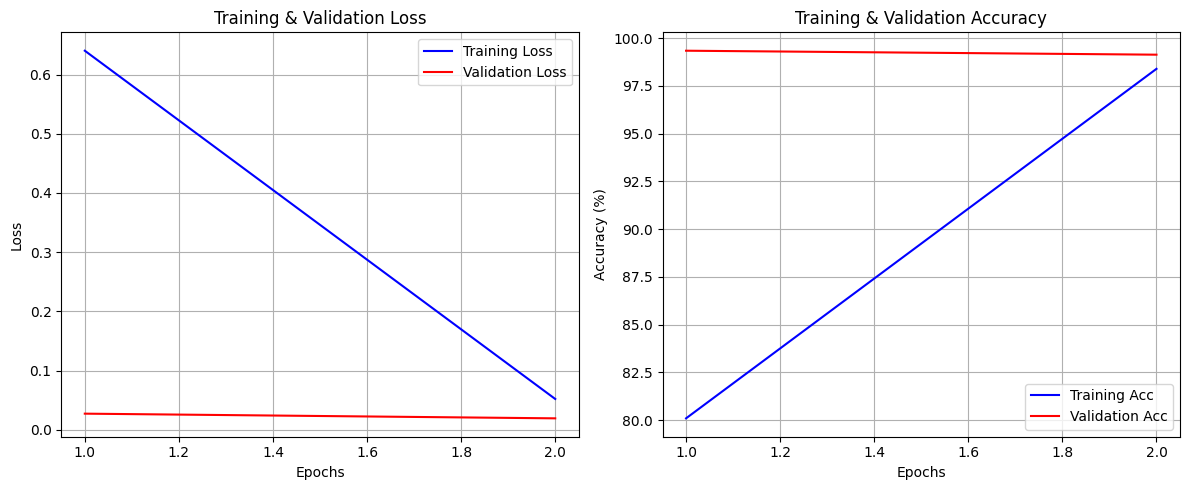

                    precision    recall  f1-score   support

    Apple Braeburn     1.0000    1.0000    1.0000        97
Apple Granny Smith     1.0000    1.0000    1.0000       102
           Apricot     1.0000    1.0000    1.0000       101
           Avocado     1.0000    1.0000    1.0000       100
            Banana     1.0000    1.0000    1.0000       102
         Blueberry     1.0000    0.8557    0.9222        97
      Cactus fruit     1.0000    1.0000    1.0000        85
        Cantaloupe     0.9877    1.0000    0.9938        80
            Cherry     1.0000    1.0000    1.0000        95
        Clementine     1.0000    1.0000    1.0000       114
              Corn     1.0000    1.0000    1.0000        86
     Cucumber Ripe     1.0000    1.0000    1.0000        89
        Grape Blue     0.9349    1.0000    0.9663       201
              Kiwi     1.0000    1.0000    1.0000        95
             Lemon     1.0000    0.9905    0.9952       105
             Limes     1.0000    1.0000

In [16]:
BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        
        # Block Konvolusi 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Opsional: Mempercepat konvergensi
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: 64x64
        )
        
        # Block Konvolusi 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Output: 32x32
        )
        
        # Block Konvolusi 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Output: 16x16
        )
        
        # Fully Connected Layers
        self.flatten = nn.Flatten()
        # Input size = 128 channel * 16 * 16 pixel
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.relu = nn.ReLU()
        
        # DROPOUT 0.2 (Sesuai Permintaan)
        self.dropout = nn.Dropout(0.2)
        
        self.fc2 = nn.Linear(512, num_classes) # Output Layer

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x) # Apply Dropout
        x = self.fc2(x)
        return x

# Inisialisasi Model
model = CustomCNN(num_classes=len(class_names)).to(device)
# print(model) # Uncomment jika ingin melihat detail layer

LEARNING_RATE = 0.01
criterion = nn.CrossEntropyLoss()
# Menggunakan SGD karena LR 0.01 cukup besar, SGD lebih stabil dibanding Adam pada LR ini.
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

def train_model(model, train_loader, valid_loader, num_epochs=15):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        model.train() # Mode Training (Dropout Aktif)
        running_loss = 0.0
        correct = 0
        total = 0
        # Loop Training
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        
        # Loop Validasi
        model.eval() # Mode Evaluasi (Dropout Mati)
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        val_loss = val_loss / len(valid_loader)
        val_acc = 100 * correct_val / total_val
        # Simpan History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Simpan Model Terbaik
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_model_cnn.pth')
            
    print(f"\n🏆 Training Selesai! Best Validation Accuracy: {best_acc:.2f}%")
    return history

history = train_model(model, train_loader, valid_loader, num_epochs=2)


def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_metrics(history)


def evaluate_model(model, test_loader):
    # Load bobot terbaik yang tersimpan saat training
    model.load_state_dict(torch.load('best_model_cnn.pth'))
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            # Pindahkan ke CPU untuk diproses Scikit-Learn
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    print(report)
    
    # Confusion Matrix Sederhana
    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix:\n", cm)

evaluate_model(model, test_loader)